In [5]:
import Student
!pip install wilds matplotlib torch torchvision terratorch umap-learn seaborn scikit-learn matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:

import ClusteringPipeline
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std

my_root_path = "/mnt/windows/Users/kevin/Downloads/"
def get_input(idx):
        """
        Returns x for a given idx.
        """
        img = Image.open(Path(my_root_path + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png').convert('RGB')
        return img



# 1. Fetch the 8-bit RGB specific statistics
tm_rgb_mean = v1_pretraining_mean['untok_sen2rgb@224']
tm_rgb_std = v1_pretraining_std['untok_sen2rgb@224']

# 2. Scale the stats down to 0.0-1.0 to match T.ToTensor()
SCALED_MEAN = [x / 255.0 for x in tm_rgb_mean]
SCALED_STD = [x / 255.0 for x in tm_rgb_std]

print(f"Scaled RGB Mean: {SCALED_MEAN}")
print(f"Scaled RGB Std:  {SCALED_STD}")

# 3. Create the Transform Pipeline
terramind_transform = T.Compose([
    T.ToTensor(),  # Scales 0-255 pixels down to 0.0-1.0
    T.Normalize(mean=SCALED_MEAN, std=SCALED_STD) # Perfectly standardizes the data
])




Scaled RGB Mean: [0.3422392156862745, 0.31737647058823526, 0.26143921568627454]
Scaled RGB Std:  [0.23045882352941177, 0.18691372549019605, 0.16718039215686276]


In [7]:
import torch.nn as nn
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_classes=6):
        super(SimpleMLP, self).__init__()
        self.layer_stack = nn.Sequential(
            # Input to Hidden
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            # Optional: Dropout helps significantly with 64 samples/class
            nn.Dropout(0.3),
            # Hidden to Output
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes=62):
        super(LinearProbe, self).__init__()
        # Nessun hidden layer, solo una proiezione diretta
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

In [8]:
import FoundationModel
# 1. Setup the pipeline and get full raw metadata
pipeline = ClusteringPipeline.ClusteringPipeline()
df_full = pipeline.get_dataset()
fm_model_base = FoundationModel.FoundationModel(name='terramind_v1_base')
fm_model_small = FoundationModel.FoundationModel(name='terramind_v1_small')
fm_model_tiny = FoundationModel.FoundationModel(name='terramind_v1_tiny')

df_sample = pipeline.sample_dataset(df_full, samples_per_class=100)

df_train_base = pipeline.get_embeddings(df_sample, fm_model_base, get_input, terramind_transform,save_path="./base")
df_train_base = pipeline.cluster_by_class(df_train_base, num_clusters=6)

df_train_small = pipeline.get_embeddings(df_sample, fm_model_small, get_input, terramind_transform,save_path="./small")
df_train_small = pipeline.cluster_by_class(df_train_small, num_clusters=6)

df_train_tiny = pipeline.get_embeddings(df_sample, fm_model_tiny, get_input, terramind_transform,save_path = "./tiny")
df_train_tiny = pipeline.cluster_by_class(df_train_tiny, num_clusters=6)

embedding_dim_base = len(df_train_base['embedding'].iloc[0])
embedding_dim_small = len(df_train_small['embedding'].iloc[0])
embedding_dim_tiny = len(df_train_tiny['embedding'].iloc[0])



TypeError: FoundationModel.__init__() got an unexpected keyword argument 'name'

In [ ]:
mlp_model = LinearProbe(input_dim=embedding_dim_small, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_small,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 8.6% | Val Acc: 14.2%
Epoch [5/100] | Train Acc: 27.1% | Val Acc: 22.1%
Epoch [10/100] | Train Acc: 33.0% | Val Acc: 24.7%
Epoch [15/100] | Train Acc: 37.1% | Val Acc: 26.8%
Epoch [20/100] | Train Acc: 39.8% | Val Acc: 28.4%
Epoch [25/100] | Train Acc: 41.6% | Val Acc: 30.4%
Epoch [30/100] | Train Acc: 44.2% | Val Acc: 29.9%
Epoch [35/100] | Train Acc: 45.8% | Val Acc: 30.5%
Epoch [40/100] | Train Acc: 47.5% | Val Acc: 31.5%
Epoch [45/100] | Train Acc: 48.9% | Val Acc: 31.4%
Epoch [50/100] | Train Acc: 50.6% | Val Acc: 30.7%
Epoch [55/100] | Train Acc: 51.3% | Val Acc: 30.7%
Epoch [60/100] | Train Acc: 53.0% | Val Acc: 31.5%
Epoch [65/100] | Train Acc: 54.3% | Val Acc: 31.9%
Epoch [70/100] | Train Acc: 55.3% | Val Acc: 31.5%
Epoch [75/100] | Train Acc: 56.1% | Val Acc: 32.3%
Epoch [80/100] | Train Acc: 56.5% | Val Acc: 32.3%
Epoch [85/100] | Train Acc: 57.1% | Val Acc: 32.1%
Epoch [90/100] | Train Acc: 58.7% | V

In [ ]:
mlp_model = LinearProbe(input_dim=embedding_dim_small, num_classes=6)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_small,
    criterion=criterion,
    optimizer=optimizer,
    target_col='macro_class',
    epochs=100
)

Preparing data for training on target: macro_class
Epoch [1/100] | Train Acc: 47.3% | Val Acc: 53.3%
Epoch [5/100] | Train Acc: 60.3% | Val Acc: 63.6%
Epoch [10/100] | Train Acc: 62.7% | Val Acc: 66.8%
Epoch [15/100] | Train Acc: 63.9% | Val Acc: 66.5%
Epoch [20/100] | Train Acc: 65.2% | Val Acc: 66.0%
Epoch [25/100] | Train Acc: 65.5% | Val Acc: 65.4%
Epoch [30/100] | Train Acc: 66.3% | Val Acc: 67.0%
Epoch [35/100] | Train Acc: 65.8% | Val Acc: 67.2%
Epoch [40/100] | Train Acc: 67.2% | Val Acc: 66.7%
Epoch [45/100] | Train Acc: 67.6% | Val Acc: 67.1%
Epoch [50/100] | Train Acc: 67.7% | Val Acc: 67.3%
Epoch [55/100] | Train Acc: 67.7% | Val Acc: 67.5%
Epoch [60/100] | Train Acc: 67.9% | Val Acc: 67.6%
Epoch [65/100] | Train Acc: 68.1% | Val Acc: 67.8%
Epoch [70/100] | Train Acc: 68.4% | Val Acc: 67.0%
Epoch [75/100] | Train Acc: 68.8% | Val Acc: 68.3%
Epoch [80/100] | Train Acc: 68.7% | Val Acc: 68.1%
Epoch [85/100] | Train Acc: 69.4% | Val Acc: 65.9%
Epoch [90/100] | Train Acc: 69.4%

In [ ]:
mlp_model = LinearProbe(input_dim=embedding_dim_tiny, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_tiny,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 5.4% | Val Acc: 10.8%
Epoch [5/100] | Train Acc: 20.1% | Val Acc: 19.0%
Epoch [10/100] | Train Acc: 24.7% | Val Acc: 21.0%
Epoch [15/100] | Train Acc: 27.2% | Val Acc: 21.3%
Epoch [20/100] | Train Acc: 29.3% | Val Acc: 23.5%
Epoch [25/100] | Train Acc: 30.7% | Val Acc: 23.7%
Epoch [30/100] | Train Acc: 31.4% | Val Acc: 23.8%
Epoch [35/100] | Train Acc: 33.1% | Val Acc: 23.9%
Epoch [40/100] | Train Acc: 33.5% | Val Acc: 24.3%
Epoch [45/100] | Train Acc: 34.9% | Val Acc: 24.5%
Epoch [50/100] | Train Acc: 35.0% | Val Acc: 24.7%
Epoch [55/100] | Train Acc: 35.9% | Val Acc: 24.6%
Epoch [60/100] | Train Acc: 36.3% | Val Acc: 24.9%
Epoch [65/100] | Train Acc: 36.8% | Val Acc: 25.0%
Epoch [70/100] | Train Acc: 37.0% | Val Acc: 25.5%
Epoch [75/100] | Train Acc: 37.9% | Val Acc: 25.2%
Epoch [80/100] | Train Acc: 38.3% | Val Acc: 26.0%
Epoch [85/100] | Train Acc: 39.1% | Val Acc: 25.6%
Epoch [90/100] | Train Acc: 38.9% | V

In [ ]:
mlp_model = LinearProbe(input_dim=embedding_dim_tiny, num_classes=6)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_tiny,
    criterion=criterion,
    optimizer=optimizer,
    target_col='macro_class',
    epochs=100
)

Preparing data for training on target: macro_class
Epoch [1/100] | Train Acc: 45.6% | Val Acc: 51.9%
Epoch [5/100] | Train Acc: 58.1% | Val Acc: 56.9%
Epoch [10/100] | Train Acc: 60.7% | Val Acc: 58.1%
Epoch [15/100] | Train Acc: 61.6% | Val Acc: 59.3%
Epoch [20/100] | Train Acc: 62.4% | Val Acc: 59.3%
Epoch [25/100] | Train Acc: 63.0% | Val Acc: 59.3%
Epoch [30/100] | Train Acc: 63.6% | Val Acc: 59.4%
Epoch [35/100] | Train Acc: 63.5% | Val Acc: 59.5%
Epoch [40/100] | Train Acc: 63.9% | Val Acc: 59.1%
Epoch [45/100] | Train Acc: 64.1% | Val Acc: 59.2%
Epoch [50/100] | Train Acc: 64.1% | Val Acc: 59.3%
Epoch [55/100] | Train Acc: 64.7% | Val Acc: 59.2%
Epoch [60/100] | Train Acc: 64.6% | Val Acc: 60.2%
Epoch [65/100] | Train Acc: 64.7% | Val Acc: 60.1%
Epoch [70/100] | Train Acc: 65.0% | Val Acc: 59.7%
Epoch [75/100] | Train Acc: 65.1% | Val Acc: 60.0%
Epoch [80/100] | Train Acc: 65.4% | Val Acc: 59.7%
Epoch [85/100] | Train Acc: 65.4% | Val Acc: 60.3%
Epoch [90/100] | Train Acc: 65.6%

In [ ]:
mlp_model = SimpleMLP(input_dim=embedding_dim_small, num_classes=6)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_small,
    criterion=criterion,
    optimizer=optimizer,
    target_col='macro_class',
    epochs=100
)

Preparing data for training on target: macro_class
Epoch [1/100] | Train Acc: 51.3% | Val Acc: 65.8%
Epoch [5/100] | Train Acc: 63.4% | Val Acc: 66.9%
Epoch [10/100] | Train Acc: 67.3% | Val Acc: 67.4%
Epoch [15/100] | Train Acc: 69.3% | Val Acc: 68.9%
Epoch [20/100] | Train Acc: 71.0% | Val Acc: 68.9%
Epoch [25/100] | Train Acc: 73.4% | Val Acc: 70.0%
Epoch [30/100] | Train Acc: 74.2% | Val Acc: 67.2%
Epoch [35/100] | Train Acc: 76.6% | Val Acc: 68.5%
Epoch [40/100] | Train Acc: 77.4% | Val Acc: 69.1%
Epoch [45/100] | Train Acc: 78.8% | Val Acc: 68.9%
Epoch [50/100] | Train Acc: 78.6% | Val Acc: 68.7%
Epoch [55/100] | Train Acc: 80.3% | Val Acc: 67.8%
Epoch [60/100] | Train Acc: 81.2% | Val Acc: 67.8%
Epoch [65/100] | Train Acc: 81.4% | Val Acc: 69.4%
Epoch [70/100] | Train Acc: 82.9% | Val Acc: 69.0%
Epoch [75/100] | Train Acc: 82.6% | Val Acc: 69.6%
Epoch [80/100] | Train Acc: 82.5% | Val Acc: 67.6%
Epoch [85/100] | Train Acc: 84.0% | Val Acc: 67.7%
Epoch [90/100] | Train Acc: 84.5%

In [ ]:
mlp_model = SimpleMLP(input_dim=embedding_dim_tiny, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-2)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_tiny,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 10.4% | Val Acc: 17.2%
Epoch [5/100] | Train Acc: 21.3% | Val Acc: 23.0%
Epoch [10/100] | Train Acc: 25.0% | Val Acc: 22.7%
Epoch [15/100] | Train Acc: 27.8% | Val Acc: 22.9%
Epoch [20/100] | Train Acc: 30.0% | Val Acc: 26.2%
Epoch [25/100] | Train Acc: 31.3% | Val Acc: 26.0%
Epoch [30/100] | Train Acc: 32.0% | Val Acc: 24.8%
Epoch [35/100] | Train Acc: 31.6% | Val Acc: 25.0%
Epoch [40/100] | Train Acc: 33.3% | Val Acc: 25.5%
Epoch [45/100] | Train Acc: 33.1% | Val Acc: 25.5%
Epoch [50/100] | Train Acc: 33.7% | Val Acc: 26.2%
Epoch [55/100] | Train Acc: 34.2% | Val Acc: 25.0%
Epoch [60/100] | Train Acc: 34.1% | Val Acc: 25.9%
Epoch [65/100] | Train Acc: 34.2% | Val Acc: 25.3%
Epoch [70/100] | Train Acc: 34.6% | Val Acc: 23.6%
Epoch [75/100] | Train Acc: 34.5% | Val Acc: 24.6%
Epoch [80/100] | Train Acc: 35.6% | Val Acc: 24.9%
Epoch [85/100] | Train Acc: 36.0% | Val Acc: 23.9%
Epoch [90/100] | Train Acc: 36.8% | 

In [ ]:
mlp_model = LinearProbe(input_dim=embedding_dim_base, num_classes=6)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_base,
    criterion=criterion,
    optimizer=optimizer,
    target_col='macro_class',
    epochs=100
)

Preparing data for training on target: macro_class
Epoch [1/100] | Train Acc: 53.8% | Val Acc: 58.7%
Epoch [5/100] | Train Acc: 68.4% | Val Acc: 64.3%
Epoch [10/100] | Train Acc: 71.0% | Val Acc: 65.2%
Epoch [15/100] | Train Acc: 72.6% | Val Acc: 66.6%
Epoch [20/100] | Train Acc: 74.1% | Val Acc: 67.8%
Epoch [25/100] | Train Acc: 74.4% | Val Acc: 67.2%
Epoch [30/100] | Train Acc: 75.3% | Val Acc: 65.8%
Epoch [35/100] | Train Acc: 75.9% | Val Acc: 66.9%
Epoch [40/100] | Train Acc: 76.4% | Val Acc: 67.7%
Epoch [45/100] | Train Acc: 76.7% | Val Acc: 67.4%
Epoch [50/100] | Train Acc: 77.2% | Val Acc: 66.7%
Epoch [55/100] | Train Acc: 77.6% | Val Acc: 68.0%
Epoch [60/100] | Train Acc: 78.1% | Val Acc: 68.0%
Epoch [65/100] | Train Acc: 78.4% | Val Acc: 67.2%
Epoch [70/100] | Train Acc: 79.0% | Val Acc: 68.4%
Epoch [75/100] | Train Acc: 78.6% | Val Acc: 66.8%
Epoch [80/100] | Train Acc: 79.4% | Val Acc: 68.4%
Epoch [85/100] | Train Acc: 78.7% | Val Acc: 67.4%
Epoch [90/100] | Train Acc: 79.7%

In [ ]:
mlp_model = LinearProbe(input_dim=embedding_dim_base, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_base,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 14.0% | Val Acc: 19.4%
Epoch [5/100] | Train Acc: 35.9% | Val Acc: 28.3%
Epoch [10/100] | Train Acc: 44.6% | Val Acc: 33.0%
Epoch [15/100] | Train Acc: 50.5% | Val Acc: 34.7%
Epoch [20/100] | Train Acc: 54.7% | Val Acc: 36.3%
Epoch [25/100] | Train Acc: 58.3% | Val Acc: 37.4%
Epoch [30/100] | Train Acc: 61.5% | Val Acc: 37.3%
Epoch [35/100] | Train Acc: 63.7% | Val Acc: 37.0%
Epoch [40/100] | Train Acc: 66.5% | Val Acc: 38.5%
Epoch [45/100] | Train Acc: 68.5% | Val Acc: 37.7%
Epoch [50/100] | Train Acc: 70.1% | Val Acc: 39.0%
Epoch [55/100] | Train Acc: 72.0% | Val Acc: 38.5%
Epoch [60/100] | Train Acc: 73.4% | Val Acc: 38.5%
Epoch [65/100] | Train Acc: 75.3% | Val Acc: 38.8%
Epoch [70/100] | Train Acc: 76.6% | Val Acc: 38.8%
Epoch [75/100] | Train Acc: 78.2% | Val Acc: 39.0%
Epoch [80/100] | Train Acc: 79.3% | Val Acc: 38.9%
Epoch [85/100] | Train Acc: 79.8% | Val Acc: 38.7%
Epoch [90/100] | Train Acc: 81.8% | 

In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
resnet_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD)
])



In [ ]:
import gc
import os

import torch


from tqdm import tqdm
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from wilds import get_dataset

# Use sklearn's LabelEncoder for tabular dataframe columns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def train_offline_resnet(model, df, criterion, optimizer, target_col='category', epochs=100, batch_size=32, log_interval=1):
    """Builds DataLoaders directly from the unified dataframe and trains the model."""
    print(f"Preparing data for training on target: {target_col}")
    # 1. Prepare Data
    X = df['index'].to_numpy()
    le = LabelEncoder()
    y = le.fit_transform(df[target_col])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.long),
                                                torch.tensor(y_train, dtype=torch.long)),
                                  batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.long),
                                               torch.tensor(y_test, dtype=torch.long)),
                                 batch_size=batch_size, shuffle=False)

    # 2. Train Loop
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X, batch_y
            imgs = []
            for idx in batch_X:
                img = get_input(idx)
                imgs.append(resnet_transform(img))
            input = torch.stack(imgs,dim=0)
            optimizer.zero_grad()
            outputs = model(input)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            del input,outputs,imgs
            gc.collect()
        train_acc = 100 * correct / total
        train_loss /= len(train_loader)

        val_loss, val_acc = evaluate_resnet(model, test_loader, criterion)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(val_acc)

        if (epoch + 1) % log_interval == 0 or epoch == 0:
            print(f"Epoch [{epoch + 1}/{epochs}] | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")

    print("\n--- Final Evaluation ---")
    final_test_loss, final_test_acc = evaluate_resnet(model, test_loader, criterion)
    print(f"Final Test Accuracy: {final_test_acc:.2f}%")
    return history

def evaluate_resnet(model, loader, criterion):
    """Internal helper for evaluation."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X, batch_y
            imgs = []
            for idx in batch_X:
                img = get_input(idx)
                imgs.append(resnet_transform(img))
            input = torch.stack(imgs,dim=0)
            outputs = model(input)
            loss = criterion(outputs, batch_y)

            running_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    return running_loss / len(loader), 100 * correct / total


In [ ]:
import Student
model = Student.Student(numberOfClasses=62)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3)
train_offline_resnet(model = model,df= df_sample,criterion=criterion,optimizer=optimizer,target_col='category',epochs=100)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 11.1% | Val Acc: 18.9%
Epoch [2/100] | Train Acc: 26.9% | Val Acc: 26.2%
Epoch [3/100] | Train Acc: 35.9% | Val Acc: 32.4%
Epoch [4/100] | Train Acc: 41.3% | Val Acc: 33.5%
Epoch [5/100] | Train Acc: 44.5% | Val Acc: 36.1%
Epoch [6/100] | Train Acc: 47.6% | Val Acc: 34.1%
Epoch [7/100] | Train Acc: 49.8% | Val Acc: 36.9%
Epoch [8/100] | Train Acc: 51.7% | Val Acc: 35.6%
Epoch [9/100] | Train Acc: 54.1% | Val Acc: 36.5%
Epoch [10/100] | Train Acc: 55.1% | Val Acc: 36.1%
Epoch [11/100] | Train Acc: 57.3% | Val Acc: 38.0%
Epoch [12/100] | Train Acc: 58.2% | Val Acc: 36.5%
Epoch [13/100] | Train Acc: 59.8% | Val Acc: 36.2%
Epoch [14/100] | Train Acc: 59.8% | Val Acc: 38.0%


KeyboardInterrupt: 

In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print(f"Parametri totali del modello: {all_params:,}")
print(f"Parametri effettivamente in addestramento: {trainable_params:,}")

Parametri totali del modello: 11,208,318
Parametri effettivamente in addestramento: 31,806


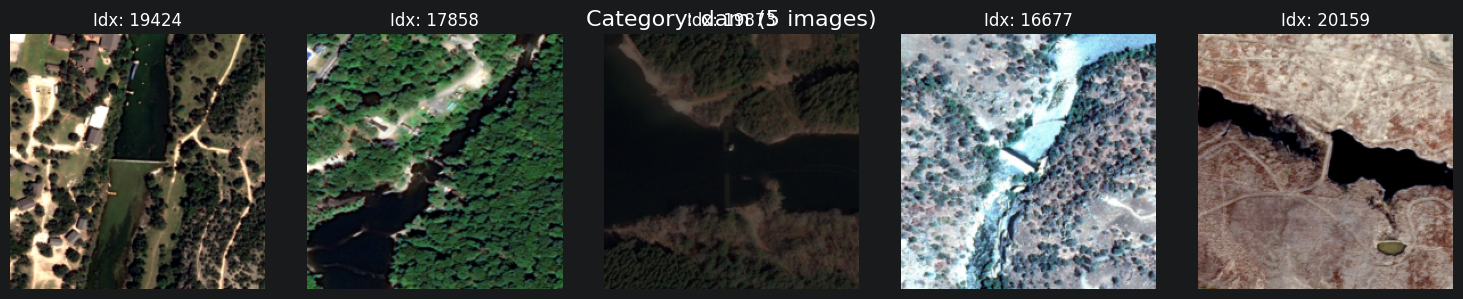

In [ ]:
pipeline.visualize_category_images(df = df_sample,category_name="airport_terminal",get_input_fn=get_input,num_images=5)